In [1]:
import os
import json
import random
import zipfile
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.model_selection import train_test_split

# COCO API
from pycocotools.coco import COCO

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [2]:
from google.colab import files

uploaded = files.upload()

Saving RMDS_segmentation_dataset_ADE20K_350.zip to RMDS_segmentation_dataset_ADE20K_350.zip


In [3]:
# Extracting Dataset

zip_path = list(uploaded.keys())[0]

extract_path = "/content/ADE20K"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [9]:
for root, dirs, files in os.walk(extract_path):
    print(root)

/content/ADE20K
/content/ADE20K/val
/content/ADE20K/train
/content/ADE20K/__MACOSX
/content/ADE20K/__MACOSX/val
/content/ADE20K/__MACOSX/train
/content/ADE20K/__MACOSX/test
/content/ADE20K/test


In [11]:
import os

# Dataset Paths

TRAIN_PATH = "/content/ADE20K/train"
VAL_PATH = "/content/ADE20K/val"
TEST_PATH = "/content/ADE20K/test"

# Correcting JSON paths based on file system output
# The JSON files are directly under /content/ADE20K, not in subdirectories.
TRAIN_JSON = os.path.join("/content/ADE20K", "instances_train.json")
VAL_JSON = os.path.join("/content/ADE20K", "instances_val.json")

print("Train Path :", TRAIN_PATH)
print("Validation Path :", VAL_PATH)
print("Test Path :", TEST_PATH)

# Loading COCO Annotation Files
from pycocotools.coco import COCO

train_coco = COCO(TRAIN_JSON)
val_coco = COCO(VAL_JSON)

print("Training images:", len(train_coco.imgs))
print("Validation images:", len(val_coco.imgs))

Train Path : /content/ADE20K/train
Validation Path : /content/ADE20K/val
Test Path : /content/ADE20K/test
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
Training images: 350
Validation images: 350


In [12]:
# Verifyind  Categories

categories = train_coco.loadCats(train_coco.getCatIds())

for cat in categories:
    if cat["name"] in ["person", "car", "book", "airplane"]:
        print(cat)

{'id': 4, 'name': 'person'}
{'id': 9, 'name': 'car'}
{'id': 40, 'name': 'book'}
{'id': 59, 'name': 'airplane'}


In [13]:
# Class Mapping

CLASS_MAP = {
    4: 1,      # person
    9: 2,      # car
    40: 3,     # book
    59: 4      # airplane
}

CLASS_NAMES = {
    0: "Background",
    1: "Person",
    2: "Car",
    3: "Book",
    4: "Airplane"
}

NUM_CLASSES = 5

print(CLASS_MAP)

{4: 1, 9: 2, 40: 3, 59: 4}


In [14]:
# Dataset Overview

print("========== DATASET OVERVIEW ==========\n")

print(f"Training Images   : {len(train_coco.imgs)}")
print(f"Validation Images : {len(val_coco.imgs)}")
print(f"Total Categories  : {len(train_coco.cats)}")

========== DATASET OVERVIEW ==========

Training Images   : 350
Validation Images : 350
Total Categories  : 100


In [16]:
# Displaying Category Names

categories = train_coco.loadCats(train_coco.getCatIds())

category_names = [cat["name"] for cat in categories]

print(category_names)

['bed', 'windowpane', 'cabinet', 'person', 'door', 'table', 'curtain', 'chair', 'car', 'painting', 'sofa', 'shelf', 'mirror', 'armchair', 'seat', 'fence', 'desk', 'wardrobe', 'lamp', 'bathtub', 'railing', 'cushion', 'box', 'column', 'signboard', 'chest of drawers', 'counter', 'sink', 'fireplace', 'refrigerator', 'stairs', 'case', 'pool table', 'pillow', 'screen door', 'bookcase', 'coffee table', 'toilet', 'flower', 'book', 'bench', 'countertop', 'stove', 'palm', 'kitchen island', 'computer', 'swivel chair', 'boat', 'arcade machine', 'bus', 'towel', 'light', 'truck', 'chandelier', 'awning', 'streetlight', 'booth', 'television receiver', 'airplane', 'apparel', 'pole', 'bannister', 'ottoman', 'bottle', 'van', 'ship', 'fountain', 'washer', 'plaything', 'stool', 'barrel', 'basket', 'bag', 'minibike', 'oven', 'ball', 'food', 'step', 'trade name', 'microwave', 'pot', 'animal', 'bicycle', 'dishwasher', 'screen', 'sculpture', 'hood', 'sconce', 'vase', 'traffic light', 'tray', 'ashcan', 'fan', '

In [17]:
# Target Classes

target_classes = ["person","car","book","airplane"]

print("Target Classes\n")

for cat in categories:

    if cat["name"] in target_classes:

        print(f"ID: {cat['id']} ---> {cat['name']}")

Target Classes

ID: 4 ---> person
ID: 9 ---> car
ID: 40 ---> book
ID: 59 ---> airplane


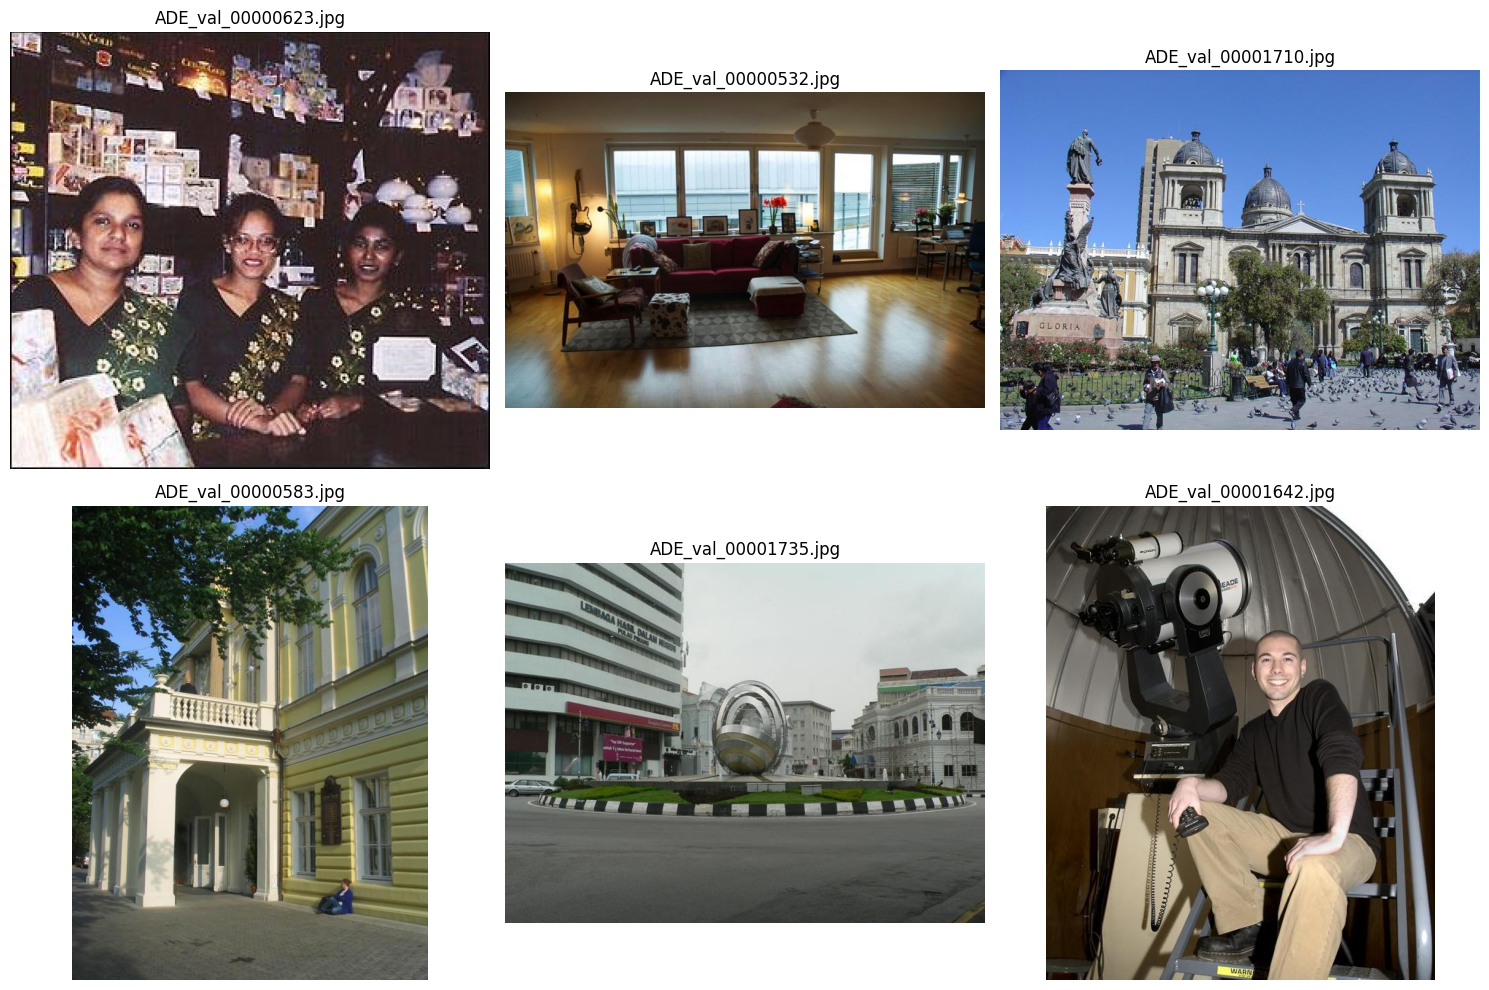

In [18]:
# Displaying Random Training Images

image_ids = list(train_coco.imgs.keys())

sample_ids = random.sample(image_ids,6)

plt.figure(figsize=(15,10))

for i,img_id in enumerate(sample_ids):

    img_info = train_coco.loadImgs(img_id)[0]

    img_path = os.path.join(TRAIN_PATH,img_info["file_name"])

    image = Image.open(img_path)

    plt.subplot(2,3,i+1)

    plt.imshow(image)

    plt.title(img_info["file_name"])

    plt.axis("off")

plt.tight_layout()

plt.show()

In [19]:
# Counting Images per Target Class

target_ids = [4,9,40,59]

class_counts = {}

for cat_id in target_ids:

    count = 0

    for img in train_coco.dataset["images"]:

        anns = train_coco.loadAnns(train_coco.getAnnIds(imgIds=img["id"]))

        found = False

        for ann in anns:

            if ann["category_id"] == cat_id:

                found = True
                break

        if found:

            count += 1

    class_counts[cat_id] = count

print(class_counts)

{4: 233, 9: 148, 40: 51, 59: 5}


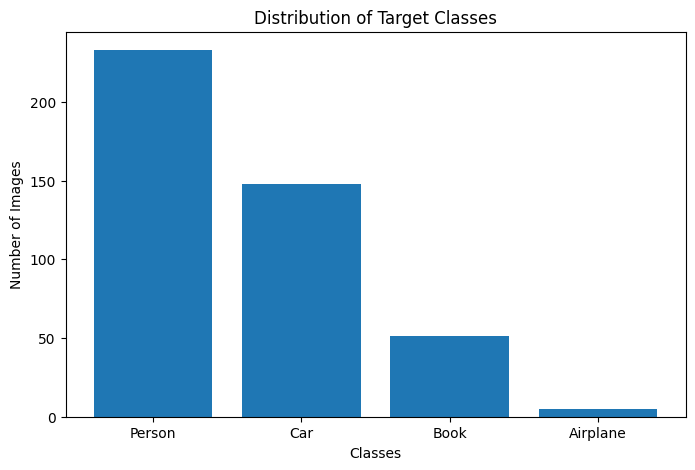

In [20]:
# Class Distribution

labels = ["Person","Car","Book","Airplane"]

values = list(class_counts.values())

plt.figure(figsize=(8,5))

plt.bar(labels,values)

plt.title("Distribution of Target Classes")

plt.xlabel("Classes")

plt.ylabel("Number of Images")

plt.show()

In [21]:
# Image Size Distribution

heights = []

widths = []

for img in train_coco.dataset["images"]:

    heights.append(img["height"])

    widths.append(img["width"])

print("Minimum Height :",min(heights))

print("Maximum Height :",max(heights))

print("Minimum Width :",min(widths))

print("Maximum Width :",max(widths))

Minimum Height : 180
Maximum Height : 975
Minimum Width : 200
Maximum Width : 975


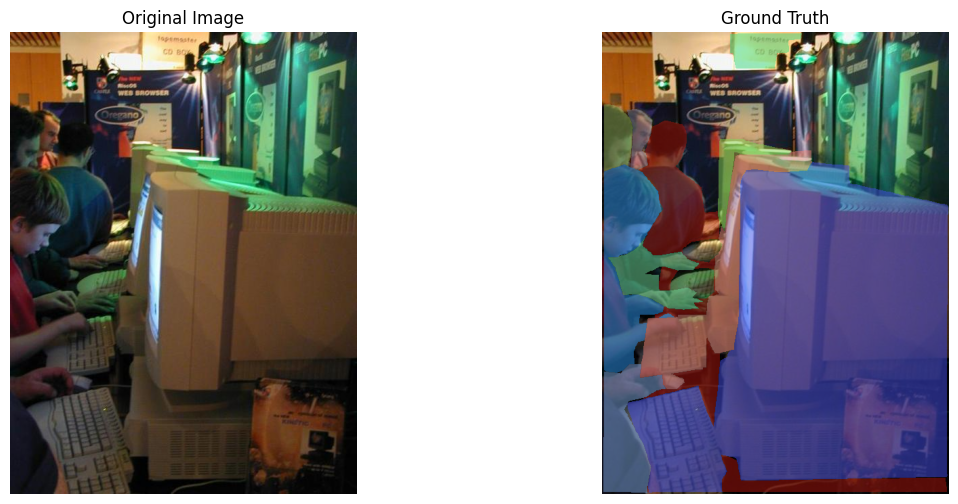

In [22]:
# Visualizing Ground Truth Masks

sample_id = random.choice(list(train_coco.imgs.keys()))

img_info = train_coco.loadImgs(sample_id)[0]

img_path = os.path.join(TRAIN_PATH,img_info["file_name"])

image = Image.open(img_path)

anns = train_coco.loadAnns(train_coco.getAnnIds(imgIds=sample_id))

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)

plt.imshow(image)

plt.title("Original Image")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(image)

train_coco.showAnns(anns)

plt.title("Ground Truth")

plt.axis("off")

plt.show()

In [23]:
# Dataset Summary

print("========== DATA SUMMARY ==========\n")

print("Training Images :",len(train_coco.imgs))

print("Validation Images :",len(val_coco.imgs))

print("Number of Categories :",len(train_coco.cats))

print("\nTarget Categories")

for cat in categories:

    if cat["id"] in [4,9,40,59]:

        print(cat["name"])

========== DATA SUMMARY ==========

Training Images : 350
Validation Images : 350
Number of Categories : 100

Target Categories
person
car
book
airplane


In [24]:
# Dataset Filtering & Mask Generation
IMG_SIZE = 256

TARGET_CLASSES = {
    4: 1,      # Person
    9: 2,      # Car
    40: 3,     # Book
    59: 4      # Airplane
}

NUM_CLASSES = 5

In [25]:
# Finding Training Images with Target Objects

train_image_ids = []

for img in train_coco.dataset["images"]:

    anns = train_coco.loadAnns(
        train_coco.getAnnIds(imgIds=img["id"])
    )

    if any(ann["category_id"] in TARGET_CLASSES for ann in anns):
        train_image_ids.append(img["id"])

print("Training Images Found:", len(train_image_ids))
print(train_image_ids[:10])

Training Images Found: 350
[21806, 20909, 20213, 21857, 21092, 20221, 20887, 21614, 21106, 21216]


In [26]:
# Finding Validation Images

val_image_ids = []

for img in val_coco.dataset["images"]:

    anns = val_coco.loadAnns(
        val_coco.getAnnIds(imgIds=img["id"])
    )

    if any(ann["category_id"] in TARGET_CLASSES for ann in anns):
        val_image_ids.append(img["id"])

print("Validation Images Found:", len(val_image_ids))

Validation Images Found: 350


In [27]:
# Creating Multi-Class Segmentation Mask
def create_mask(coco, img_id):

    img_info = coco.loadImgs(img_id)[0]

    h = img_info["height"]
    w = img_info["width"]

    mask = np.zeros((h, w), dtype=np.uint8)

    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)

    for ann in anns:

        category = ann["category_id"]

        if category not in TARGET_CLASSES:
            continue

        object_mask = coco.annToMask(ann)

        mask[object_mask == 1] = TARGET_CLASSES[category]

    return mask

Unique labels: [0 3]


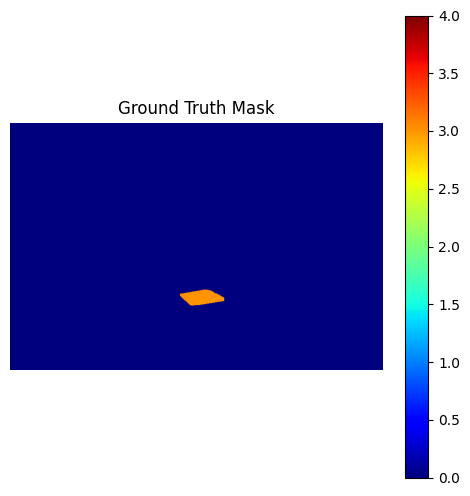

In [28]:
# Visualising One Mask

sample_id = random.choice(train_image_ids)

mask = create_mask(train_coco, sample_id)

print("Unique labels:", np.unique(mask))

plt.figure(figsize=(6,6))
plt.imshow(mask, cmap="jet", vmin=0, vmax=4)
plt.colorbar()
plt.title("Ground Truth Mask")
plt.axis("off")
plt.show()

In [29]:
# Loading Training Images and Masks

train_images = []
train_masks = []

for img_id in train_image_ids:

    info = train_coco.loadImgs(img_id)[0]

    img_path = os.path.join(TRAIN_PATH, info["file_name"])

    image = Image.open(img_path).convert("RGB")
    image = image.resize((IMG_SIZE, IMG_SIZE))

    image = np.array(image, dtype=np.float32) / 255.0

    mask = create_mask(train_coco, img_id)
    mask = Image.fromarray(mask)
    mask = mask.resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)
    mask = np.array(mask, dtype=np.uint8)

    train_images.append(image)
    train_masks.append(mask)

train_images = np.array(train_images, dtype=np.float32)
train_masks = np.array(train_masks, dtype=np.uint8)

print(train_images.shape)
print(train_masks.shape)

(350, 256, 256, 3)
(350, 256, 256)


In [30]:
# Loading Validation Images and Masks

val_images = []
val_masks = []

for img_id in val_image_ids:

    info = val_coco.loadImgs(img_id)[0]

    img_path = os.path.join(VAL_PATH, info["file_name"])

    image = Image.open(img_path).convert("RGB")
    image = image.resize((IMG_SIZE, IMG_SIZE))

    image = np.array(image, dtype=np.float32) / 255.0

    mask = create_mask(val_coco, img_id)
    mask = Image.fromarray(mask)
    mask = mask.resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)
    mask = np.array(mask, dtype=np.uint8)

    val_images.append(image)
    val_masks.append(mask)

val_images = np.array(val_images, dtype=np.float32)
val_masks = np.array(val_masks, dtype=np.uint8)

print(val_images.shape)
print(val_masks.shape)

(350, 256, 256, 3)
(350, 256, 256)


In [31]:
# Verifying Labels

print("Training Labels :", np.unique(train_masks))
print("Validation Labels:", np.unique(val_masks))

Training Labels : [0 1 2 3 4]
Validation Labels: [0 1 2 3 4]


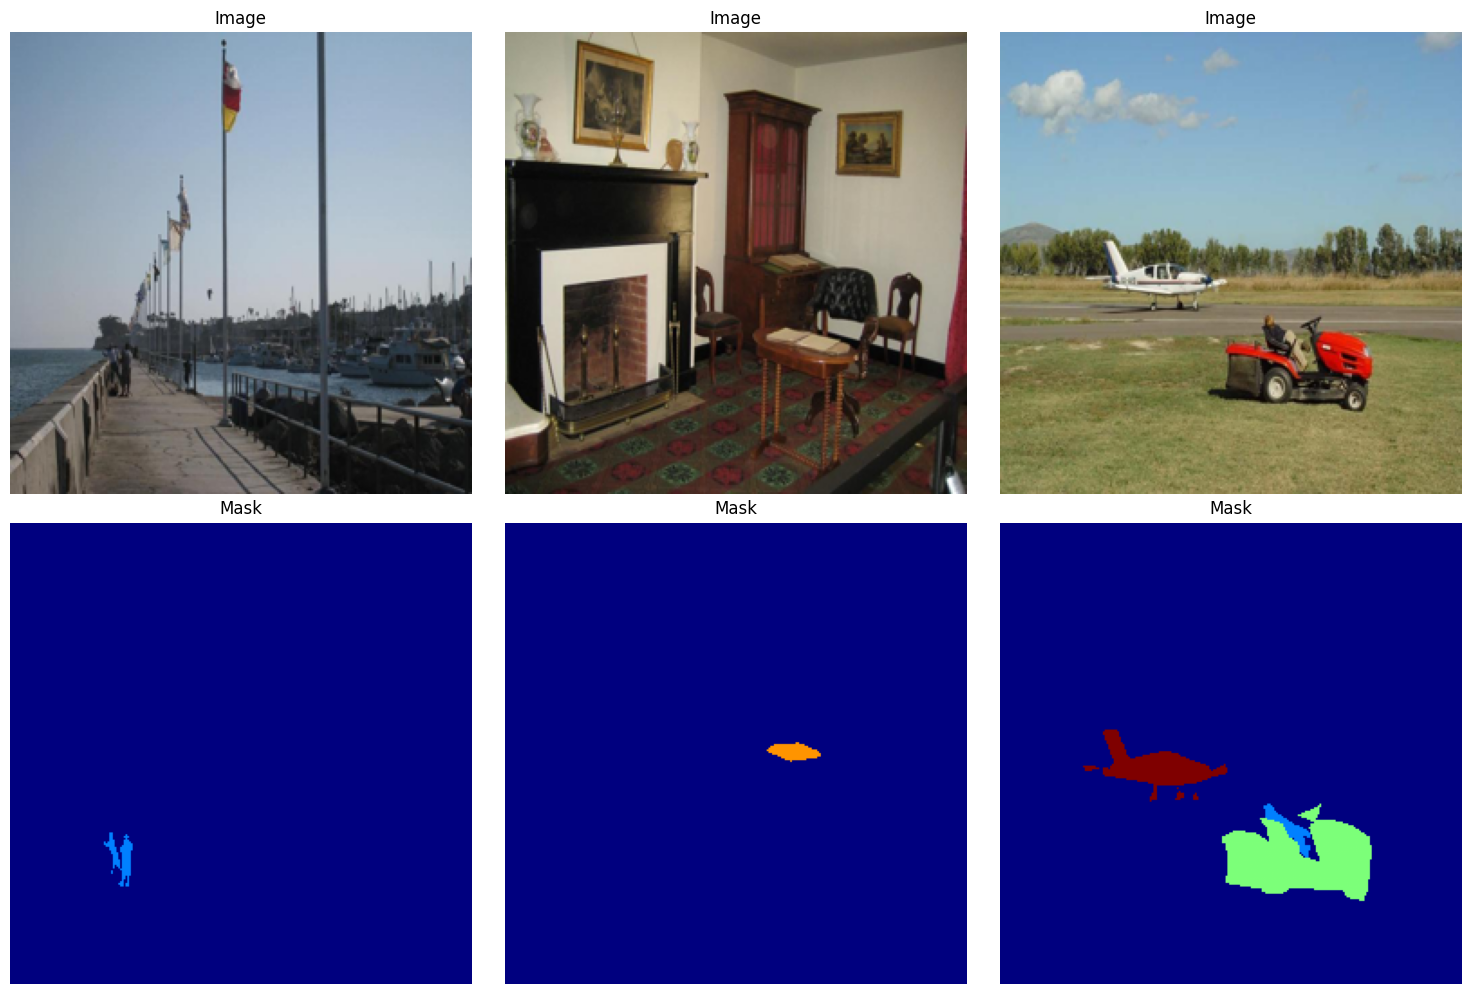

In [32]:
# Displaying Samples

plt.figure(figsize=(15,10))

for i in range(3):

    plt.subplot(2,3,i+1)
    plt.imshow(train_images[i])
    plt.title("Image")
    plt.axis("off")

    plt.subplot(2,3,i+4)
    plt.imshow(train_masks[i], cmap="jet", vmin=0, vmax=4)
    plt.title("Mask")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [60]:
#TensorFlow Dataset Pipeline
print("Training Images Shape :", train_images.shape)
print("Training Masks Shape  :", train_masks.shape)

print("Validation Images Shape :", val_images.shape)
print("Validation Masks Shape  :", val_masks.shape)

Training Images Shape : (350, 256, 256, 3)
Training Masks Shape  : (350, 256, 256)
Validation Images Shape : (350, 256, 256, 3)
Validation Masks Shape  : (350, 256, 256)


In [61]:
# Converting Masks

train_masks = train_masks.astype(np.uint8)
val_masks = val_masks.astype(np.uint8)

print(train_masks.dtype)
print(val_masks.dtype)

uint8
uint8


In [62]:
# Hyperparameters

BATCH_SIZE = 8
AUTOTUNE = tf.data.AUTOTUNE

print("Batch Size:", BATCH_SIZE)

Batch Size: 8


In [63]:
# Building Training Dataset

train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_images, train_masks)
)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (val_images, val_masks)
)

In [64]:
# Dataset Preprocessing

def preprocess(image, mask):

    image = tf.cast(image, tf.float32)

    mask = tf.cast(mask, tf.uint8)

    return image, mask

In [65]:
# Applying Preprocessing

train_dataset = train_dataset.map(
    preprocess,
    num_parallel_calls=AUTOTUNE
)

val_dataset = val_dataset.map(
    preprocess,
    num_parallel_calls=AUTOTUNE
)

In [66]:
# Optimizing Dataset Pipeline

train_dataset = (
    train_dataset
    .shuffle(500)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_dataset = (
    val_dataset
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [67]:
# Verifying Dataset

for images, masks in train_dataset.take(1):

    print("Images :", images.shape)
    print("Masks  :", masks.shape)

Images : (8, 256, 256, 3)
Masks  : (8, 256, 256)


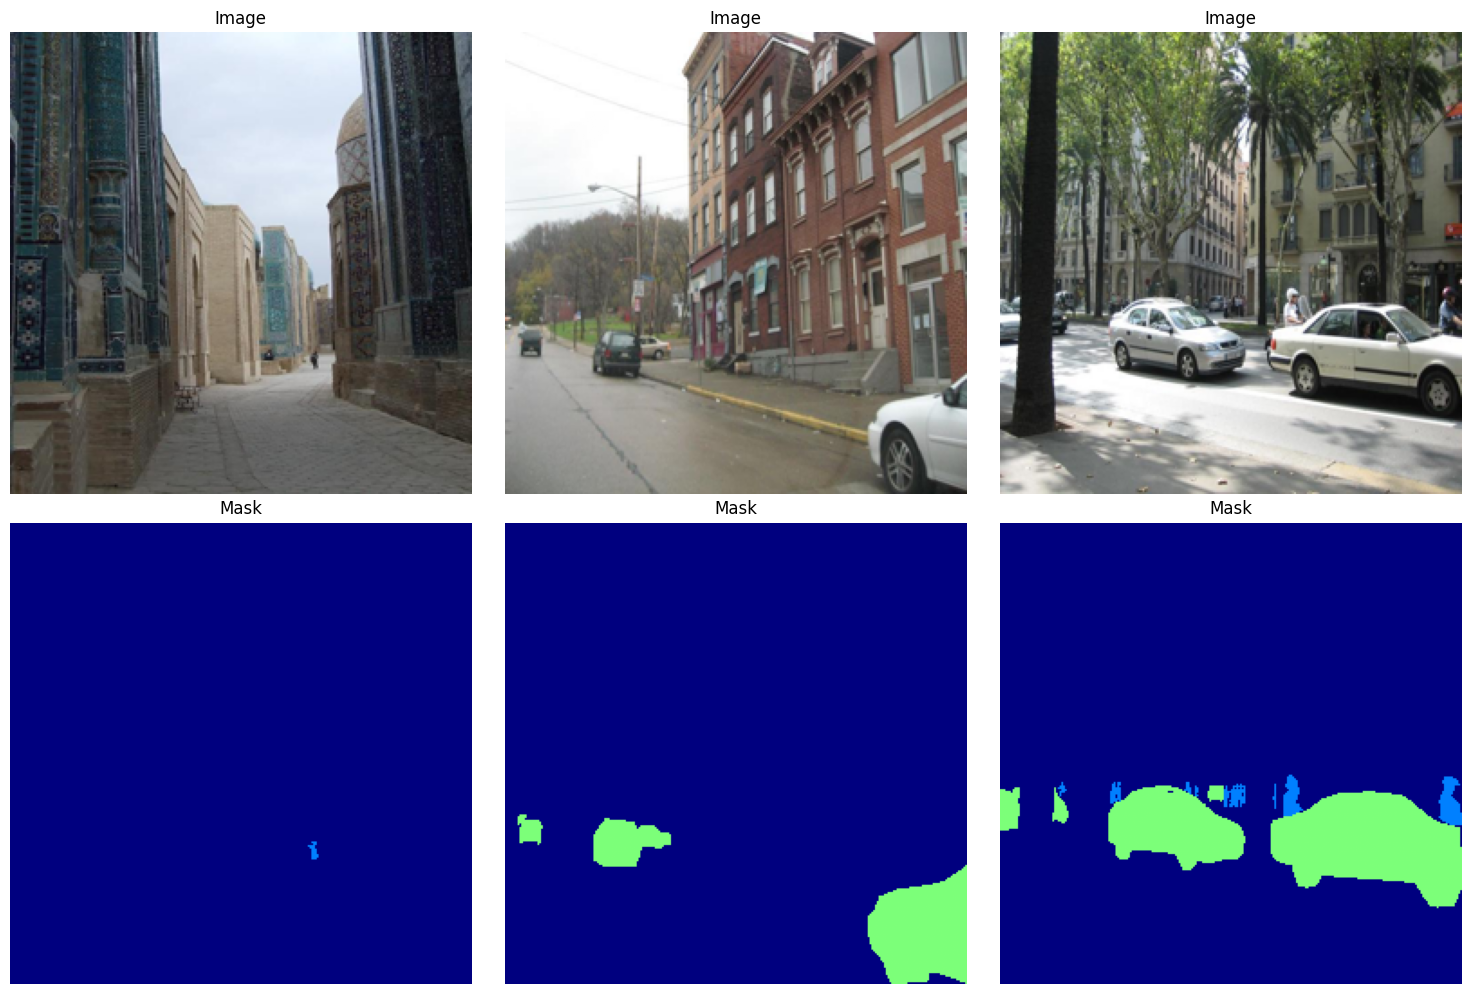

In [68]:
# Visualizing Training Batch

for images, masks in train_dataset.take(1):

    plt.figure(figsize=(15,10))

    for i in range(3):

        plt.subplot(2,3,i+1)
        plt.imshow(images[i])
        plt.title("Image")
        plt.axis("off")

        plt.subplot(2,3,i+4)
        plt.imshow(masks[i], cmap="jet", vmin=0, vmax=4)
        plt.title("Mask")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [69]:
#U-Net Model

from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Conv2DTranspose,
    concatenate,
    BatchNormalization,
    Activation,
    Dropout
)

def conv_block(inputs, filters):

    x = Conv2D(filters, 3, padding="same")(inputs)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv2D(filters, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    return x

In [70]:
def encoder_block(inputs, filters):

    x = conv_block(inputs, filters)

    p = MaxPooling2D((2,2))(x)

    p = Dropout(0.2)(p)

    return x, p

In [71]:
def decoder_block(inputs, skip, filters):

    x = Conv2DTranspose(filters, 2, strides=2, padding="same")(inputs)

    x = concatenate([x, skip])

    x = Dropout(0.2)(x)

    x = conv_block(x, filters)

    return x

In [72]:
IMG_SIZE = 256
NUM_CLASSES = 5

inputs = Input((IMG_SIZE, IMG_SIZE, 3))

# Encoder
s1, p1 = encoder_block(inputs, 64)
s2, p2 = encoder_block(p1, 128)
s3, p3 = encoder_block(p2, 256)
s4, p4 = encoder_block(p3, 512)

# Bridge
b1 = conv_block(p4, 1024)

# Decoder
d1 = decoder_block(b1, s4, 512)
d2 = decoder_block(d1, s3, 256)
d3 = decoder_block(d2, s2, 128)
d4 = decoder_block(d3, s1, 64)

outputs = Conv2D(
    NUM_CLASSES,
    1,
    activation="softmax"
)(d4)

model = Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 256, 256,  │      1,792 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 256, 256,  │     36,928 │ activation_18[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 128, 128,  │          0 │ activation_19[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 128, 128,  │          0 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 128, 128,  │     73,856 │ dropout_8[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 128, 128,  │    147,584 │ activation_20[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 64, 64,    │          0 │ activation_21[0]… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 64, 64,    │          0 │ max_pooling2d_5[

 Total params: 31,055,557 (118.47 MB)

 Trainable params: 31,043,781 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

In [73]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")
    ]
)

In [74]:
# Callbacks

checkpoint = ModelCheckpoint(

    "best_unet.keras",

    monitor="val_loss",

    save_best_only=True,

    verbose=1

)

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=8,

    restore_best_weights=True,

    verbose=1

)

In [75]:
# Model trainig
EPOCHS = 30

history = model.fit(

    train_dataset,

    validation_data=val_dataset,

    epochs=EPOCHS,

    callbacks=[
        checkpoint,
        early_stop
    ]

)

Epoch 1/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3577 - loss: 1.6559   
Epoch 1: val_loss improved from None to 1.37282, saving model to best_unet.keras

Epoch 1: finished saving model to best_unet.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step - accuracy: 0.5837 - loss: 1.3664 - val_accuracy: 0.9309 - val_loss: 1.3728
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.9138 - loss: 0.7962
Epoch 2: val_loss improved from 1.37282 to 1.00104, saving model to best_unet.keras

Epoch 2: finished saving model to best_unet.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 35s 802ms/step - accuracy: 0.9238 - loss: 0.7208 - val_accuracy: 0.9311 - val_loss: 1.0010
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.9304 - loss: 0.5941
Epoch 3: val_loss improved from 1.00104 to 0.78164, saving model to best_unet.keras

Epoch 3: finished saving model to best_unet.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 35s 796ms/step - accuracy: 0.9306 - loss: 0.5763 - val_accuracy: 0.9311 - val_l

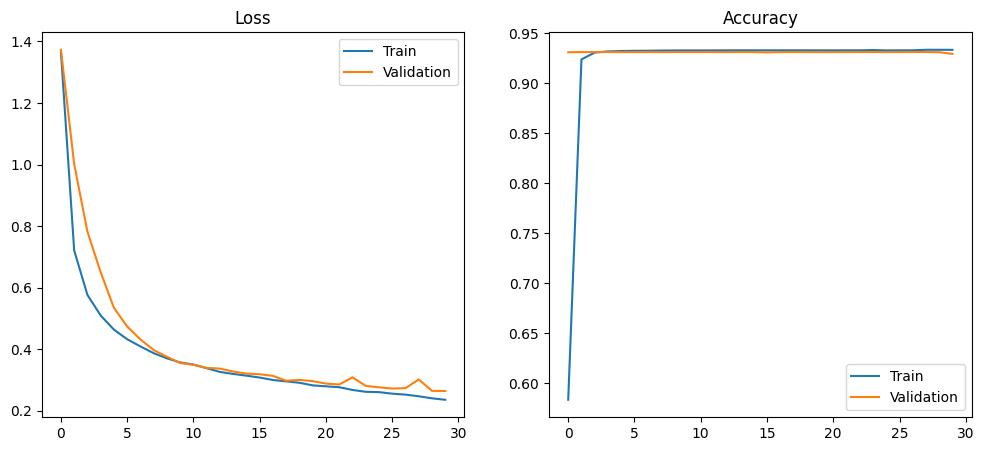

In [76]:
#Training Curves
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")

plt.title("Loss")

plt.legend()

plt.subplot(1,2,2)

plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.title("Accuracy")

plt.legend()

plt.show()

In [77]:
model.save("ADE20K_UNet_Model.keras")

print("Model saved successfully.")

Model saved successfully.


In [78]:
#Evaluation of the Model

results = model.evaluate(val_dataset)

print("\nValidation Results")
print("---------------------")
print(f"Validation Loss     : {results[0]:.4f}")
print(f"Validation Accuracy : {results[1]:.4f}")

44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 176ms/step - accuracy: 0.9293 - loss: 0.2644

Validation Results
---------------------
Validation Loss     : 0.2644
Validation Accuracy : 0.9293


In [79]:
# Predicting Validation Images

predictions = model.predict(val_images)

pred_masks = np.argmax(predictions, axis=-1)

print(pred_masks.shape)

11/11 ━━━━━━━━━━━━━━━━━━━━ 109s 6s/step
(350, 256, 256)


In [80]:
# Pixel Accuracy

pixel_accuracy = np.mean(pred_masks == val_masks)

print(f"Pixel Accuracy: {pixel_accuracy:.4f}")

Pixel Accuracy: 0.9293


In [81]:
# Mean IoU

iou_metric = tf.keras.metrics.MeanIoU(num_classes=NUM_CLASSES)

iou_metric.update_state(val_masks, pred_masks)

print("Mean IoU:", iou_metric.result().numpy())

Mean IoU: 0.20450214


In [82]:
# Dice Score

def dice_score(y_true, y_pred):

    scores = []

    for cls in range(1, NUM_CLASSES):

        true_cls = (y_true == cls)
        pred_cls = (y_pred == cls)

        intersection = np.logical_and(true_cls, pred_cls).sum()

        denominator = true_cls.sum() + pred_cls.sum()

        if denominator == 0:
            continue

        dice = (2.0 * intersection) / denominator

        scores.append(dice)

    return np.mean(scores)

dice = dice_score(val_masks, pred_masks)

print(f"Dice Score: {dice:.4f}")

Dice Score: 0.0427


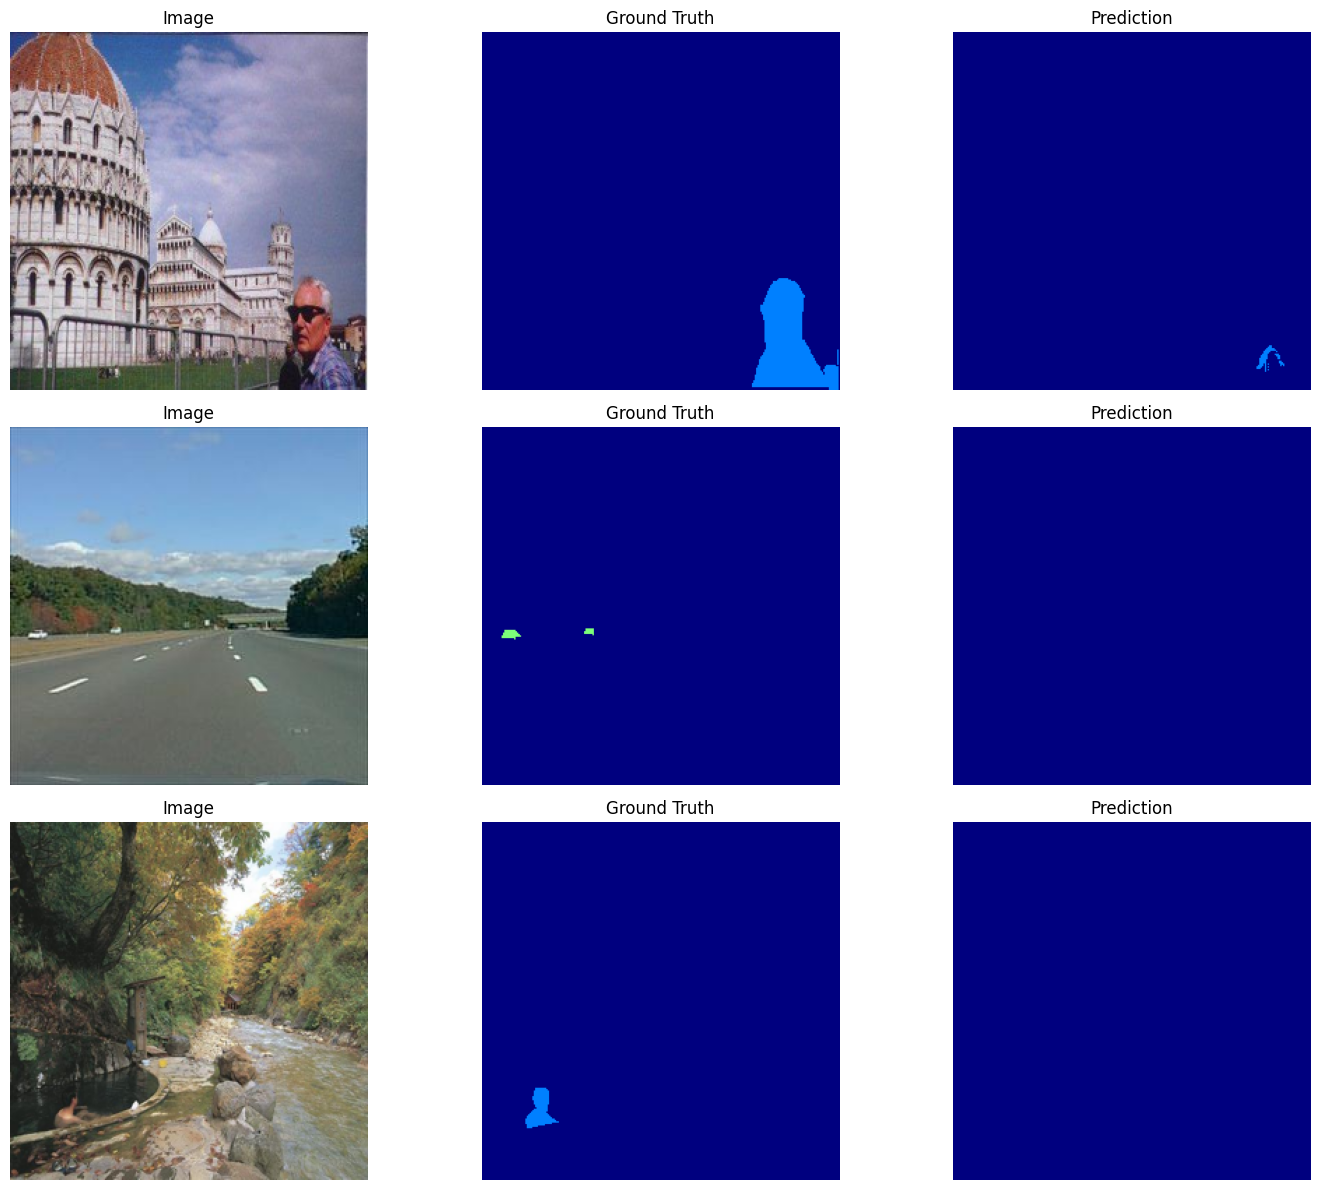

In [83]:
# Comparison of Ground Truth vs Prediction

plt.figure(figsize=(15,12))

samples = random.sample(range(len(val_images)),3)

for i, idx in enumerate(samples):

    plt.subplot(3,3,3*i+1)
    plt.imshow(val_images[idx])
    plt.title("Image")
    plt.axis("off")

    plt.subplot(3,3,3*i+2)
    plt.imshow(val_masks[idx], cmap="jet", vmin=0, vmax=4)
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(3,3,3*i+3)
    plt.imshow(pred_masks[idx], cmap="jet", vmin=0, vmax=4)
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [84]:
#Test Images

test_files = sorted([
    f for f in os.listdir(TEST_PATH)
    if f.endswith(".jpg")
])

print("Total Test Images:", len(test_files))

Total Test Images: 30


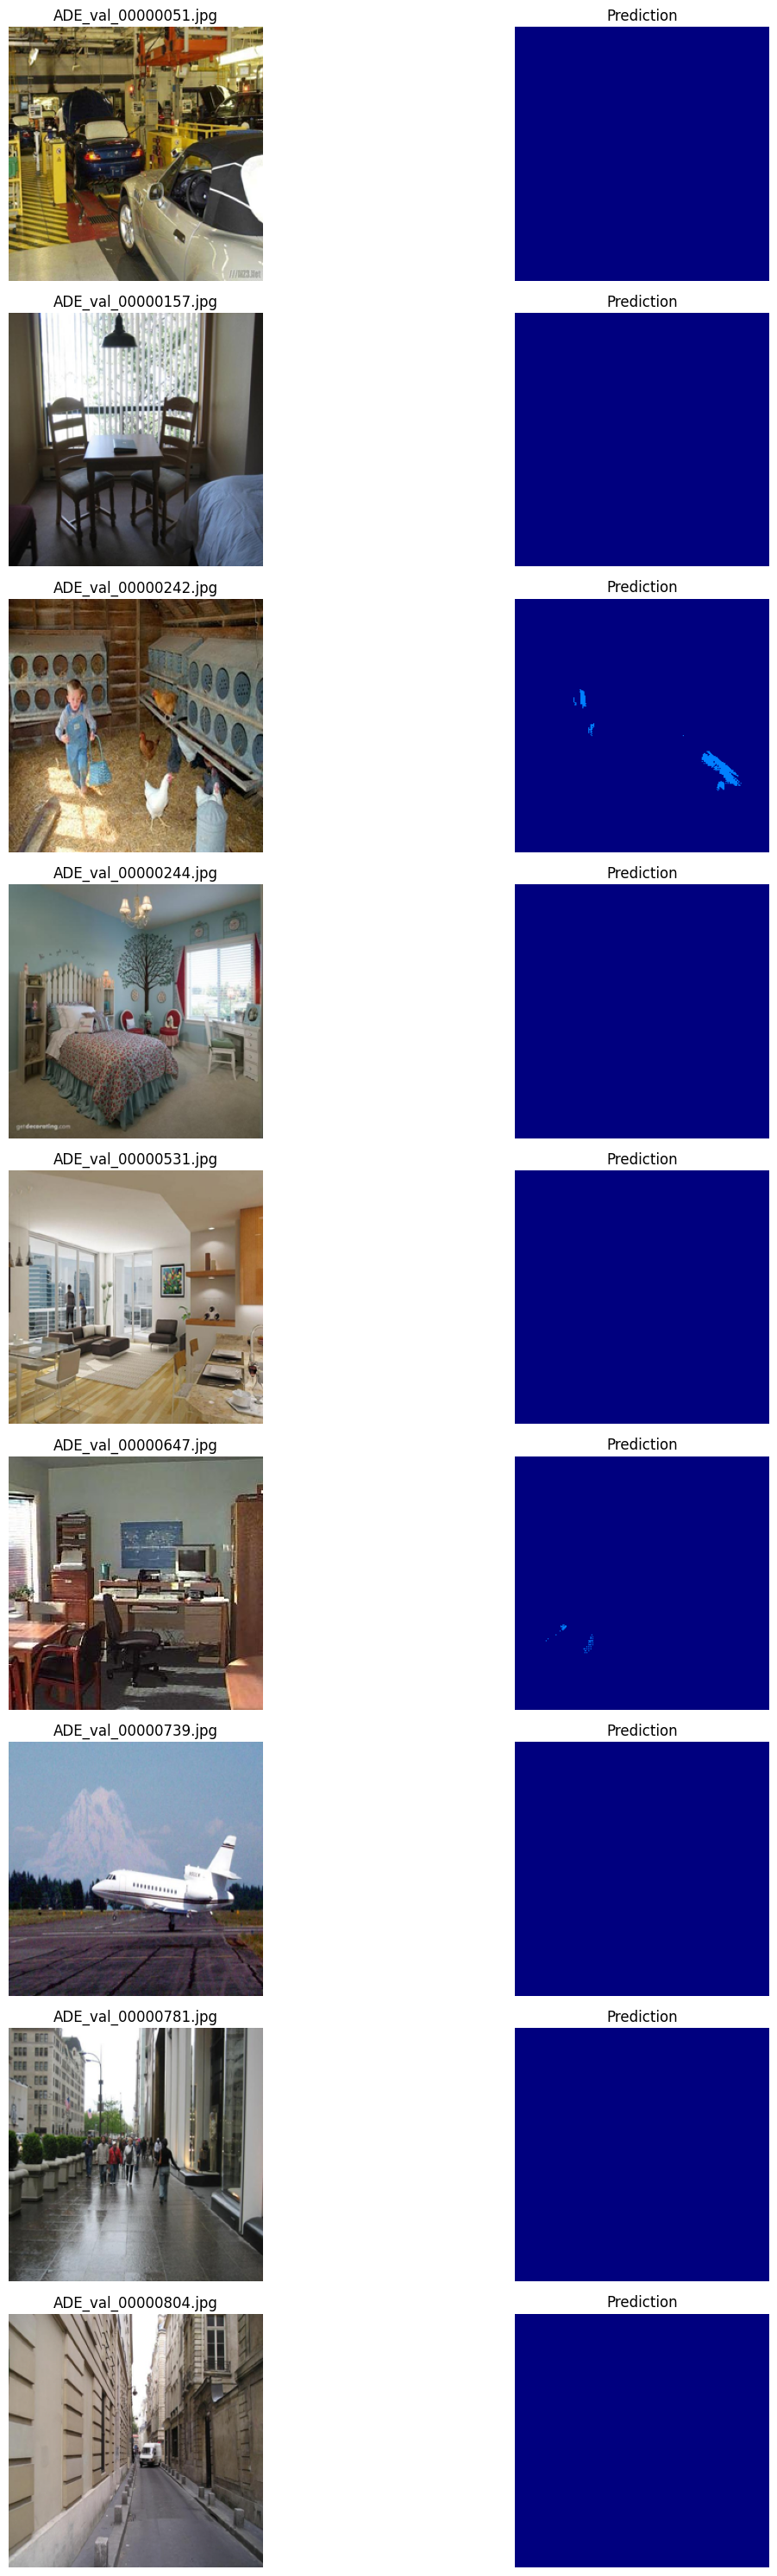

In [88]:
# Prediction of  Test Images

plt.figure(figsize=(15,30))

for i, file in enumerate(test_files[:9]):

    img = Image.open(os.path.join(TEST_PATH,file)).convert("RGB")

    img = img.resize((IMG_SIZE,IMG_SIZE))

    img_array = np.array(img,dtype=np.float32)/255.0

    prediction = model.predict(
        np.expand_dims(img_array,0),
        verbose=0
    )

    prediction = np.argmax(prediction[0],axis=-1)

    plt.subplot(9,2,2*i+1)
    plt.imshow(img)
    plt.title(file)
    plt.axis("off")

    plt.subplot(9,2,2*i+2)
    plt.imshow(prediction,cmap="jet",vmin=0,vmax=4)
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [86]:
# Saving the Predicted Masks

OUTPUT_DIR = "Predicted_Masks"

os.makedirs(OUTPUT_DIR, exist_ok=True)

for file in test_files:

    img = Image.open(os.path.join(TEST_PATH,file)).convert("RGB")

    img = img.resize((IMG_SIZE,IMG_SIZE))

    img_array = np.array(img,dtype=np.float32)/255.0

    prediction = model.predict(
        np.expand_dims(img_array,0),
        verbose=0
    )

    prediction = np.argmax(prediction[0],axis=-1)

    Image.fromarray(prediction.astype(np.uint8)).save(
        os.path.join(OUTPUT_DIR,file.replace(".jpg","_mask.png"))
    )

print("All predicted masks have been saved.")

All predicted masks have been saved.
